# **🚲 Bike Sharing Demand Prediction**

## **Overview :**

This project builds a regression pipeline to predict hourly bike rental demand (cnt) using the UCI Bike Sharing dataset — historical rental data from Washington D.C.'s Capital Bikeshare system, combined with weather and calendar information.

### **Objective :**

Given time, weather, and calendar conditions (hour of day, season, temperature, humidity, working day, etc.), predict how many bikes will be rented in that hour. Accurate demand forecasting like this supports fleet rebalancing, staffing, and inventory decisions for bike-share operators.

### **Dataset**

Source: UCI Machine Learning Repository (hour.csv).

~17,379 rows, hourly records spanning 2011–2012.

## Approach

1- **Data cleaing.**

2- **EDA.**

3- **Feature engineering.**

4- **Outlier handling.**

5- **bliud a perprossering pipline .**

6- **Modeling ,experiment tracking..**

7- **Hyperparameter tuning.**

8- **Evaluation.**

9- **Deployment.**



### Production Environment Setup

**NumPy** : Summon the elemental forces of arrays and numerical computation.

**Pandas** :loading, cleaning, and reshaping the bike-share records.

**Matplotlib** & **Seaborn** : Paint your data stories with the colors of insight.

***MLflow*** : The scrying mirror — records every experiment's parameters, metrics, and artifacts.

***Joblib*** : Safely store your magical artifacts (models and transformers).

***JSON*** : Speak the language of configuration spirits — model cards and deployment requirements, written for future summoners to read.

***datetime***, ***os***, ***time*** : Track time, navigate your data realm, and record every step of your journey — from timestamped model versions to training-time measurements.

**Scikit-learn** : The great arsenal — Pipeline and ColumnTransformer to chain your spells in order, RobustScaler and custom transformers (AdvancedFeatureEngineer, OutlierHandler) to purify raw data, Ridge/Lasso/RandomForest/GradientBoosting/SVR/VotingRegressor as your council of competing, RandomizedSearchCV to fine-tune their prophecies.

In [84]:
import numpy as np
import  matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import joblib
import json
import os
import time


# Sklearn libraries - expanded for advanced ML workflows


from sklearn.model_selection import (
    train_test_split,     # Split data into train/test sets
    cross_val_score,      # Cross-validation scoring
    GridSearchCV,         # Hyperparameter tuning (grid search)
    RandomizedSearchCV    # Hyperparameter tuning (randomized search)
)
from sklearn.preprocessing import (
    StandardScaler,       # Feature scaling (zero-mean, unit variance)
    RobustScaler,         # Scaling robust to outliers
    PolynomialFeatures    # Generate polynomial features for non-linear relationships
)
from sklearn.pipeline import Pipeline, FeatureUnion  # Build modular pipelines
from sklearn.compose import ColumnTransformer         # Apply different preprocessing to columns
from sklearn.feature_selection import (
    SelectKBest,          # Univariate feature selection
    f_regression,         # Scoring function for regression
    RFE                   # Recursive feature elimination
)
from sklearn.linear_model import (
    LinearRegression,     # Baseline regression
    Ridge,                # L2-regularized regression
    Lasso,                # L1-regularized regression
    ElasticNet            # Combination of L1 and L2 regularization
)
from sklearn.ensemble import (
    RandomForestRegressor,       # Ensemble of decision trees
    GradientBoostingRegressor,   # Boosted trees for regression
    VotingRegressor              # Combine multiple regressors
)
from sklearn.svm import SVR               # Support Vector Regression
from sklearn.metrics import (
    mean_squared_error,  # Regression metric
    r2_score,            # Regression metric
    mean_absolute_error  # Regression metric
)

# Advanced model tracking with MLflow
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"
import mlflow    # Experiment tracking
import mlflow.sklearn   # Log sklearn models
from mlflow.models.signature import infer_signature

## **Key Components:**

1-**Reproducibility**

- RANDOM_STATE = 42: Ensures that every run produces the same train/test splits, random  sampling, and model results.
- TEST_SIZE = 0.2: Reserves 20% of the data for final evaluation.
- VAL_SIZE = 0.2: Reserves a portion of the training data for validation and hyperparameter tuning.
- CV_FOLDS = 5: Use 5-fold cross-validation to evaluate models robustly.
- N_JOBS = -1: Utilizes all available CPU cores to speed up computations.

2-**Organized Project Structure**

- MODEL_DIR = "models": All trained models are stored in a dedicated folder.
- EXPERIMENT_DIR = "experiments": All MLflow experiment logs, metrics, and artifacts are saved in a centralized location.
- os.makedirs(..., exist_ok=True): Ensures directories exist, preventing file errors during training or logging.

3-**MLflow Experiment Tracking**

- mlflow.set_tracking_uri(...) points MLflow to the experiment folder.
- mlflow.set_experiment(experiment_name) creates a named experiment for this project.
This allows you to log models, metrics, and hyperparameters, enabling easy comparison across experiments.


In [85]:
# My controal screen
class Config:
    RANDOM_STATE = 42
    TEST_SIZE = 0.2
    VAL_SIZE = 0.2
    CV_FOLDS = 5
    N_JOBS = -1

    MODEL_DIR = "models"
    EXPERIMENT_DIR = "experiments"

    # Create Directories If They Don't Exist
    os.makedirs(MODEL_DIR, exist_ok=True)
    os.makedirs(EXPERIMENT_DIR, exist_ok=True)

config = Config()

# Initialize MLflow for experiment tracking
mlflow.set_tracking_uri(f"file://{os.path.abspath(config.EXPERIMENT_DIR)}")
experiment_name = "Diabetes_Test"
mlflow.set_experiment(experiment_name)

<Experiment: artifact_location='file:///Users/usertwo/loka/two/project/src/project/experiments/410290973187596847', creation_time=1789410345851, effective_trace_archival_retention=None, experiment_id='410290973187596847', last_update_time=1789410345851, lifecycle_stage='active', name='Diabetes_Test', tags={}, trace_location=None, workspace='default'>

I'm dropping dteday because the useful information contained in the date has already been represented by:
yr
mnth
weekday
hr.

casual + redistered riders is the cnt (which is the target) thats why i dropped it:
casual is the number of casual riders.
registered is the number of registered riders

The instant
It doesn't describe the weather, time, or actual bike demand

In [86]:
# load Data

print("Loading Diabetes Dataset...")
df = pd.read_csv("../bike/hour.csv")

# X = df.drop(columns=["cnt","instant", "dteday", "casual", "registered"])
X = df.drop(columns=['cnt', 'casual', 'registered', 'dteday'])  # drop target + leakage columns
y = df['cnt']

print(f'Dataset shape: {df.shape}')
print(f'Dataset features: {df.columns}')
df.head()

Loading Diabetes Dataset...
Dataset shape: (17379, 17)
Dataset features: Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='str')


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


### **Exploratory Data Analysis (EDA)**

Before building models, we must understand our data:

- Check for missing values
- Understand distributions
- Detect outliers
- Explore relationships between features

In [87]:
# Basic statistics
print("=" * 70)
print("📊 DATASET STATISTICS")
print("=" * 70)
print(df.describe())

📊 DATASET STATISTICS
          instant        season            yr          mnth            hr  \
count  17379.0000  17379.000000  17379.000000  17379.000000  17379.000000   
mean    8690.0000      2.501640      0.502561      6.537775     11.546752   
std     5017.0295      1.106918      0.500008      3.438776      6.914405   
min        1.0000      1.000000      0.000000      1.000000      0.000000   
25%     4345.5000      2.000000      0.000000      4.000000      6.000000   
50%     8690.0000      3.000000      1.000000      7.000000     12.000000   
75%    13034.5000      3.000000      1.000000     10.000000     18.000000   
max    17379.0000      4.000000      1.000000     12.000000     23.000000   

            holiday       weekday    workingday    weathersit          temp  \
count  17379.000000  17379.000000  17379.000000  17379.000000  17379.000000   
mean       0.028770      3.003683      0.682721      1.425283      0.496987   
std        0.167165      2.005771      0.465431 

In [88]:
# Missing values check
print("\n" + "=" * 88)
print("🔍 MISSING VALUES CHECK")
print("=" * 70)
print(df.isnull().sum())


🔍 MISSING VALUES CHECK
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


### **Missing Values Check**

All datasets were inspected, and no missing values were found — great news! ✅
This means every feature is complete and ready for modeling.

If missing values were present, we could handle them using these common imputation strategies:

- Mean → Replace with the column’s average (for normal numeric data).
- Median → Replace with the middle value (robust to outliers).
- Most Frequent (Mode) → Replace with the most common value (for categorical data).
These techniques ensure data consistency and prevent model bias caused by incomplete records.

In [89]:
# Data types
print("\n" + "=" * 88)
print("📋 DATA TYPES")
print("=" * 70)
print(df.dtypes)


📋 DATA TYPES
instant         int64
dteday            str
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object


### **Data Type Check**

All feature data types were verified and found to be clean and consistent — no unexpected types detected except one (dteday) which alreday deleted cause the useful information contained in the date has already been represented by: yr, mnth, weekday, hr. 

If data type issues had appeared (for example, categorical columns mixed with numeric ones), we could preprocess them using:

- One-Hot Encoding → Convert categorical features into numerical vectors.
- ColumnTransformer → Apply different preprocessing steps to different feature types.

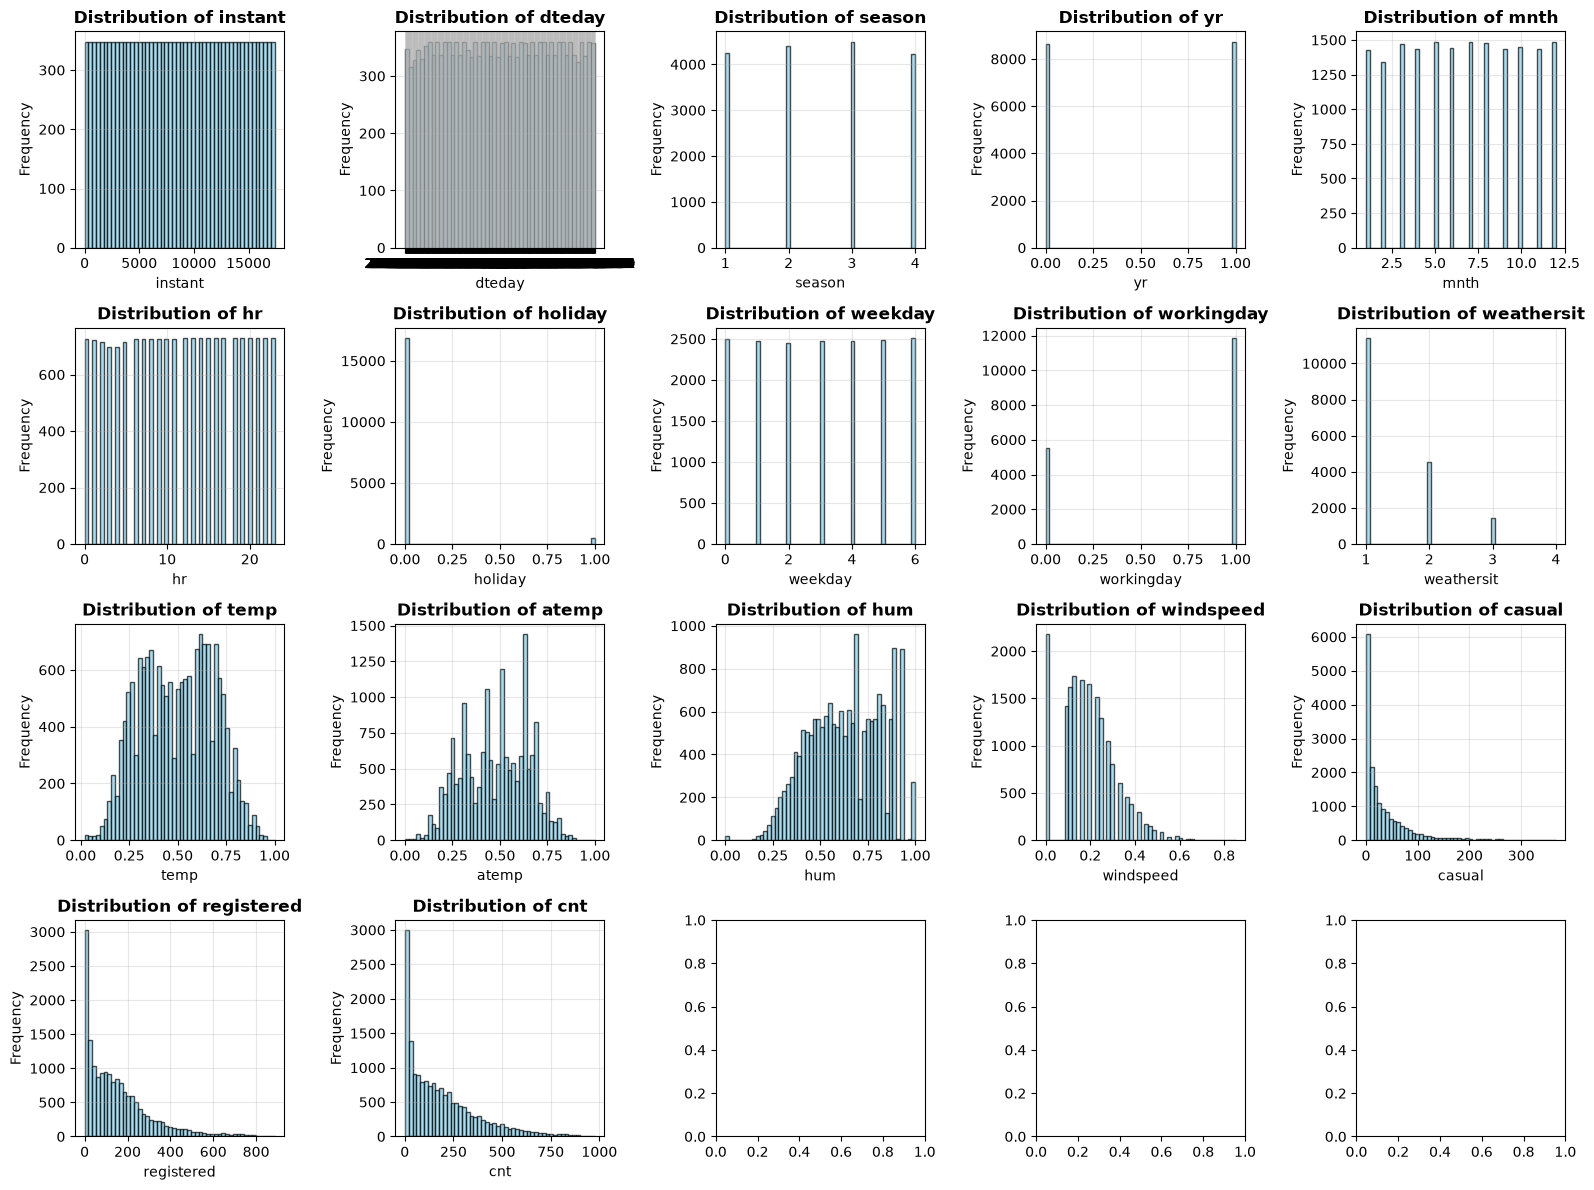

In [90]:
# Distribution visualizations
fig, axes = plt.subplots(4, 5, figsize=(16, 12))
axes = axes.ravel()

for idx, col in enumerate(df.columns):
    axes[idx].hist(df[col], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

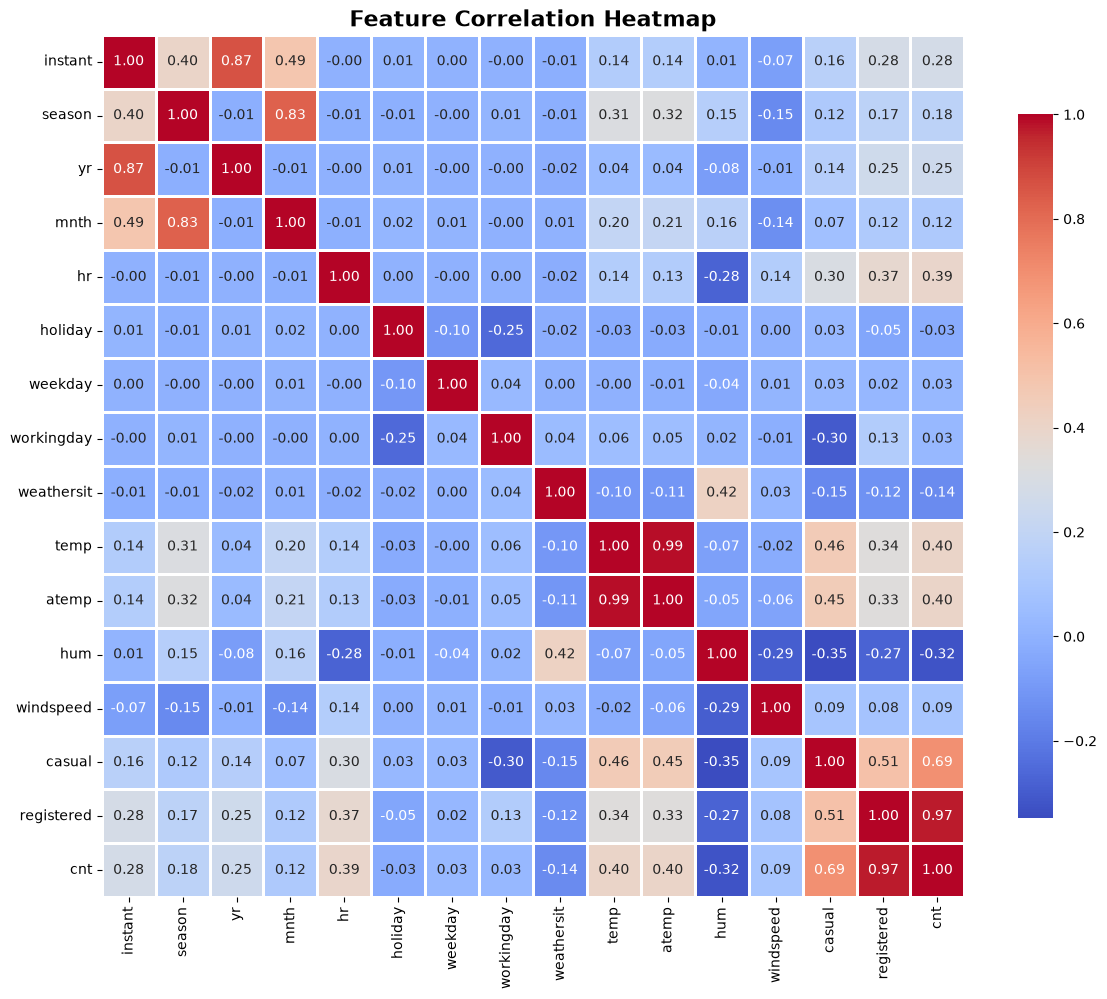


🎯 FEATURES RANKED BY CORRELATION WITH cnt
registered        0.9722
casual            0.6946
temp              0.4048
atemp             0.4009
hr                0.3941
instant           0.2784
yr                0.2505
season            0.1781
mnth              0.1206
windspeed         0.0932
workingday        0.0303
weekday           0.0269
holiday          -0.0309
weathersit       -0.1424
hum              -0.3229


In [91]:
# Correlation matrix
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Feature importance ranking
print("\n" + "=" * 70)
print("🎯 FEATURES RANKED BY CORRELATION WITH cnt")
print("=" * 70)
correlations = correlation_matrix['cnt'].drop('cnt').sort_values(ascending=False)
for feature, corr in correlations.items():
    print(f"{feature:<15} {corr:>8.4f}")

###  **Feature Engineering & Data Preprocessing**

In [92]:
from sklearn.base import BaseEstimator, TransformerMixin


class AdvancedFeatureEngineer(BaseEstimator, TransformerMixin):
    """Advanced feature engineering for the Bike Sharing dataset."""

    def __init__(self):
        self.feature_names = []

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_eng = X.copy()

        # Working Day × Hour
        # Captures different hourly demand patterns
        # between working and non-working days
        X_eng["WorkingDay_Hour_Interaction"] = (
            X_eng["workingday"] * X_eng["hr"]
        )

        # Temperature × Humidity
        # Captures combined weather/comfort effect
        X_eng["Temperature_Humidity_Interaction"] = (
            X_eng["temp"] * X_eng["hum"]
        )

        # Store feature names
        self.feature_names = list(X_eng.columns)

        return X_eng

    def fit_transform(self, X, y=None):
        self.fit(X, y)
        return self.transform(X)

    def get_feature_names(self):
        return self.feature_names


# Test feature engineering
engineer = AdvancedFeatureEngineer()

X_engineered = engineer.fit_transform(X)

print("\n🎯 FEATURE ENGINEERING COMPLETE!")
print(f"• Original features: {X.shape[1]}")
print(f"• Engineered features: {X_engineered.shape[1]}")
print(f"• New features: {engineer.feature_names[-2:]}")



🎯 FEATURE ENGINEERING COMPLETE!
• Original features: 13
• Engineered features: 15
• New features: ['WorkingDay_Hour_Interaction', 'Temperature_Humidity_Interaction']


 Outlier Handling with IQR — Making the Data More Robust

🧮 **IQR Outlier Detection Logic**

For each feature:

1- Calculate **Q1 (25th percentile)** and **Q3 (75th percentile)**.

2- Compute **IQR = Q3 − Q1**.

3- Define:
                **Lower Bound = Q1 - 1.5 * IQR  Upper Bound = Q3 + 1.5 * IQR**

4- Clip any values outside this range to make the distribution more stable.

In [93]:
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin


class OutlierHandler(BaseEstimator, TransformerMixin):
    """Handle outliers using the IQR method."""

    def __init__(self, factor=1.5):
        self.factor = factor
        self.lower_bounds_ = None
        self.upper_bounds_ = None

    def fit(self, X, y=None):

        self.lower_bounds_ = {}
        self.upper_bounds_ = {}

        # Calculate IQR bounds for each column
        for column in X.columns:

            Q1 = X[column].quantile(0.25)
            Q3 = X[column].quantile(0.75)

            IQR = Q3 - Q1

            self.lower_bounds_[column] = (
                Q1 - self.factor * IQR
            )

            self.upper_bounds_[column] = (
                Q3 + self.factor * IQR
            )

        return self

    def transform(self, X):

        X_transformed = X.copy()

        # Clip each feature to its IQR bounds
        for column in X.columns:

            lower = self.lower_bounds_[column]
            upper = self.upper_bounds_[column]

            X_transformed[column] = X_transformed[column].clip(
                lower=lower,
                upper=upper
            )

        return X_transformed


### **Building the Final Preprocessing Pipeline**

We’ve now developed and tested each individual component of our preprocessing workflow:

1- 🧠 **AdvancedFeatureEngineer** → creates new domain-informed features (e.g., distance from center, ratios, interactions).

2- 🧹 **OutlierHandler** → detects and clips extreme values using the IQR method for robust statistics.

3- 📏 **RobustScaler** → scales features in a way that’s less sensitive to outliers compared to StandardScaler.

In [94]:
# Create comprehensive preprocessing pipeline
preprocessor = Pipeline([
    ('feature_engineer', AdvancedFeatureEngineer()),  # Our new features
    ('outlier_handler', OutlierHandler(factor=1.5)),  # Handle outliers
    ('scaler', RobustScaler())  # Robust to outliers (better than StandardScaler)
])

# Apply preprocessing pipeline
print("🔄 Applying preprocessing pipeline...")
X_processed = preprocessor.fit_transform(X, y)

print("✅ ADVANCED PREPROCESSING PIPELINE BUILT!")
print(f"📊 Processed data shape: {X_processed.shape}")
print(f"🎯 All feature names: {preprocessor.named_steps['feature_engineer'].get_feature_names()}")


🔄 Applying preprocessing pipeline...
✅ ADVANCED PREPROCESSING PIPELINE BUILT!
📊 Processed data shape: (17379, 15)
🎯 All feature names: ['instant', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'WorkingDay_Hour_Interaction', 'Temperature_Humidity_Interaction']


### Better Approach: Train / Validation / Test Split

To solve these issues, we add a validation set between training and testing:

- 🧠 **Train set** → Used to train the model.
- 🧪 **Validation set** → Used to tune hyperparameters, early stopping, and model selection.
- 🧭 **Test set** → Kept completely unseen until the very end for final evaluation.

This separation ensures:

- ✅ Cleaner model evaluation
- ✅ More reliable hyperparameter tuning
- ✅ Reduced overfitting to the test set
- ✅ More realistic production performance estimation


#### **Implementation**

In [95]:
# Improved data splitting with validation set
X_temp, X_test, y_temp, y_test = train_test_split(
    X_processed, y, test_size=config.TEST_SIZE, random_state=config.RANDOM_STATE
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=config.VAL_SIZE, random_state=config.RANDOM_STATE
)


print(f"📊 DATA SPLITS (IMPROVED from previous notebook):")
print(f"• Training: {X_train.shape[0]:,} samples (model learning)")
print(f"• Validation: {X_val.shape[0]:,} samples (hyperparameter tuning)") 
print(f"• Test: {X_test.shape[0]:,} samples (final evaluation - NEVER TOUCHED until end)")

📊 DATA SPLITS (IMPROVED from previous notebook):
• Training: 11,122 samples (model learning)
• Validation: 2,781 samples (hyperparameter tuning)
• Test: 3,476 samples (final evaluation - NEVER TOUCHED until end)


## 🆕 Introducing Advanced Models

We now upgrade our model set to include a **diverse mix of linear, regularized, tree-based, and ensemble learners**:

| Model Name                     | Type                  | Why We Add It 🧭                                                    |
| ------------------------------ | --------------------- | ------------------------------------------------------------------- |
| `LinearRegression`             | Linear Baseline       | A clean baseline — interpretable and fast.                          |
| `Ridge Regression`             | Regularized Linear    | Controls overfitting with L2 regularization.                        |
| `Lasso Regression`             | Regularized Linear    | Performs **feature selection** via L1 penalty.                      |
| `ElasticNet` 🆕                | Hybrid Regularization | Combines L1 + L2 — more flexible for correlated features.           |
| `RandomForestRegressor` 🆕     | Tree Ensemble         | Handles nonlinearities & interactions without feature engineering.  |
| `GradientBoostingRegressor` 🆕 | Boosting Ensemble     | Learns sequentially, improving weak learners over time.             |
| `Support Vector Regression` 🆕 | Kernel Method         | Captures complex relationships using kernel tricks.                 |
| `VotingRegressor` 🆕           | Ensemble Strategy     | Combines multiple models for **stronger, more stable performance**. |

---

## ⚡ Why This Matters in Production

✅ **Model diversity** improves your chances of finding a high-performing model.
✅ **Regularized models** give stability and interpretability.
✅ **Ensemble methods** usually outperform single models in complex tasks.
✅ **Nonlinear models** can capture patterns linear models miss.

This setup also makes it easy to:

* 📊 Compare models consistently
* 🧪 Run hyperparameter tuning later
* 🧠 Blend models into a **final ensemble**

---

## 🧱 Implementation



In [96]:
# define advanced models - Expanded from previous work
advanced_models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(random_state=config.RANDOM_STATE),
    'Lasso Regression': Lasso(random_state=config.RANDOM_STATE),
    'ElasticNet': ElasticNet(random_state=config.RANDOM_STATE),  # NEW: Combines L1 + L2
    'Random Forest': RandomForestRegressor(random_state=config.RANDOM_STATE, n_jobs=config.N_JOBS),
    'Gradient Boosting': GradientBoostingRegressor(random_state=config.RANDOM_STATE),  # NEW: Sequential learning
    'Support Vector Regression': SVR(),  # NEW: Different approach
}

# NEW: Voting Ensemble - Combines multiple models
voting_ensemble = VotingRegressor([
    ('ridge', Ridge(random_state=config.RANDOM_STATE)),
    ('rf', RandomForestRegressor(random_state=config.RANDOM_STATE, n_jobs=config.N_JOBS)),
    ('gb', GradientBoostingRegressor(random_state=config.RANDOM_STATE))
])

advanced_models['Voting Ensemble'] = voting_ensemble

print(f"\n🎯 MODEL PORTFOLIO ({len(advanced_models)} models):")


🎯 MODEL PORTFOLIO (8 models):


### 🚀 Full Advanced Model Evaluation (All-in-One)

This implementation runs the **entire model evaluation workflow in a single function**:

1. **Train the model** → records training time.
2. **Evaluate on training and validation sets** → computes RMSE, R², MAE, and overfitting gap.
3. **Cross-validation** → estimates model stability and performance variability across folds.
4. **MLflow logging** → automatically logs hyperparameters, metrics, and saves the model artifact.
5. **Loop over multiple models** → trains, evaluates, and tracks all models in one go, reporting **validation R², cross-validation mean ± std, and overfitting warnings**.

In [98]:
def evaluate_model_advanced(model, X_train, X_val, y_train, y_val, model_name):
    """Comprehensive model evaluation with MLflow tracking"""
    
    # Start MLflow run for experiment tracking
    with mlflow.start_run(run_name=model_name):
        # Train model with timing
        start_time = time.time()
        model.fit(X_train, y_train)
        training_time = time.time() - start_time
        
        # Predictions on both sets
        y_train_pred = model.predict(X_train)
        y_val_pred = model.predict(X_val)
        
        # Calculate comprehensive metrics
        metrics = {
            'train_rmse': np.sqrt(mean_squared_error(y_train, y_train_pred)),
            'val_rmse': np.sqrt(mean_squared_error(y_val, y_val_pred)),
            'train_r2': r2_score(y_train, y_train_pred),
            'val_r2': r2_score(y_val, y_val_pred),
            'train_mae': mean_absolute_error(y_train, y_train_pred),
            'val_mae': mean_absolute_error(y_val, y_val_pred),
            'training_time': training_time,
            'overfitting_gap': r2_score(y_train, y_train_pred) - r2_score(y_val, y_val_pred)
        }
        
        # AUTOMATIC TRACKING with MLflow
        mlflow.log_params(model.get_params())  # Log hyperparameters
        mlflow.log_metrics({k: v for k, v in metrics.items() if k != 'training_time'})
        mlflow.sklearn.log_model(model, "model",skops_trusted_types=[
        "sklearn.utils._bunch.Bunch"])  # Save model artifact
        
        # Cross-validation for robust performance estimate
        cv_scores = cross_val_score(model, X_train, y_train, 
                                  cv=config.CV_FOLDS, scoring='r2', n_jobs=1)
        metrics['cv_r2_mean'] = cv_scores.mean()
        metrics['cv_r2_std'] = cv_scores.std()
        
        mlflow.log_metrics({
            'cv_r2_mean': metrics['cv_r2_mean'],
            'cv_r2_std': metrics['cv_r2_std']
        })
        
        return metrics, model

print("🚀 STARTING ADVANCED MODEL EVALUATION...")
print("Each model is being trained, evaluated, and tracked in MLflow")

results = {}
trained_models = {}

for name, model in advanced_models.items():
    print(f"\n🔧 Training {name}...")
    metrics, trained_model = evaluate_model_advanced(
        model, X_train, X_val, y_train, y_val, name
    )
    results[name] = metrics
    trained_models[name] = trained_model
    
    # Progress reporting
    overfitting_indicator = "⚠️" if metrics['overfitting_gap'] > 0.1 else "✅"
    print(f"✅ {name:20} | Val R²: {metrics['val_r2']:.4f} | "
          f"CV R²: {metrics['cv_r2_mean']:.4f} ± {metrics['cv_r2_std']:.4f} "
          f"{overfitting_indicator}")

print(f"\n📈 All models trained and tracked in MLflow!")
print(f"💡 Check MLflow UI: mlflow ui --backend-store-uri {config.EXPERIMENT_DIR}")

2026/09/15 12:36:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🚀 STARTING ADVANCED MODEL EVALUATION...
Each model is being trained, evaluated, and tracked in MLflow

🔧 Training Linear Regression...


2026/09/15 12:36:14 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/09/15 12:36:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ Linear Regression    | Val R²: 0.4007 | CV R²: 0.3966 ± 0.0155 ✅

🔧 Training Ridge Regression...


2026/09/15 12:36:21 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/09/15 12:36:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


...

✅ Gradient Boosting    | Val R²: 0.9001 | CV R²: 0.8937 ± 0.0038 ✅

🔧 Training Support Vector Regression...


2026/09/15 12:37:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/15 12:37:37 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


✅ Support Vector Regression | Val R²: 0.3720 | CV R²: 0.3468 ± 0.0240 ✅

🔧 Training Voting Ensemble...


2026/09/15 12:38:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/15 12:38:30 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


✅ Voting Ensemble      | Val R²: 0.8664 | CV R²: 0.8568 ± 0.0041 ✅

📈 All models trained and tracked in MLflow!
💡 Check MLflow UI: mlflow ui --backend-store-uri experiments


## 📊 Model Comparison & Visualization

In this section, we summarize and visualize the performance of all trained models. 

- First, we convert the `results` dictionary into a readable table.  
- Then, we create simple plots for key metrics to help interpret model performance:

1. **Validation R²** → Higher is better ✅  
2. **Validation RMSE** → Lower is better ✅  
3. **Overfitting Gap** → Closer to 0 is better ⚖️  

These visualizations make it easy for both technical and non-technical users to compare models at a glance.

📊 Model comparison table:


,Model,val_r2,val_rmse,val_mae,overfitting_gap,cv_r2_mean
0,Linear Regression,0.400683,139.779469,104.263308,-0.002699,0.396588
1,Ridge Regression,0.400705,139.776928,104.257808,-0.002726,0.396598
2,Lasso Regression,0.398426,140.042446,104.481974,-0.003144,0.394012
3,ElasticNet,0.322341,148.634907,111.919569,-0.001233,0.320419
4,Random Forest,0.946777,41.654664,25.100137,0.045736,0.942249
5,Gradient Boosting,0.900117,57.063746,38.786091,0.001323,0.893676
6,Support Vector Regression,0.371969,143.088875,93.179892,-0.006602,0.346757
7,Voting Ensemble,0.866382,66.000582,48.107420,0.014773,0.856797


/var/folders/6_/_ffygjtd70b4hxh0dgzrnc500000gp/T/ipykernel_27238/3755585424.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metrics_df, x='Model', y='val_r2', palette='viridis')
/Users/usertwo/loka/two/project/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


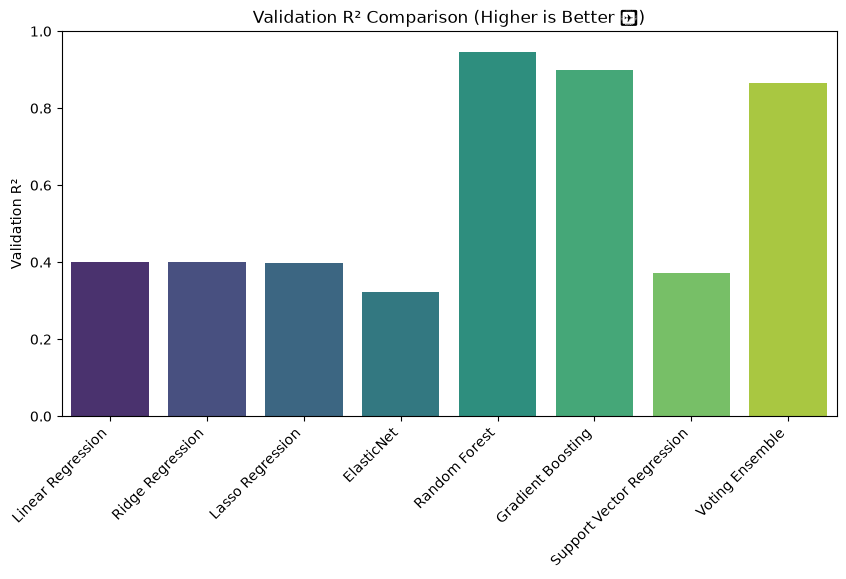

/var/folders/6_/_ffygjtd70b4hxh0dgzrnc500000gp/T/ipykernel_27238/3755585424.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metrics_df, x='Model', y='val_rmse', palette='magma')
/Users/usertwo/loka/two/project/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


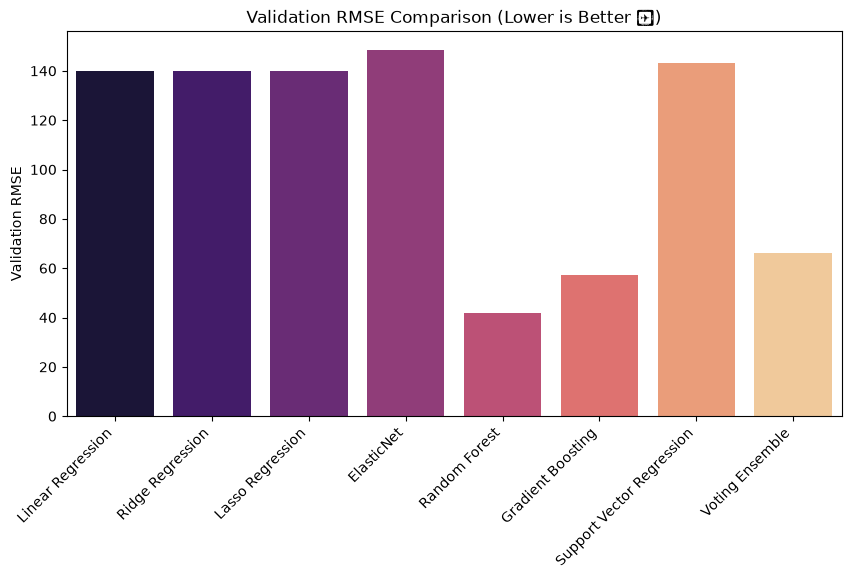

/var/folders/6_/_ffygjtd70b4hxh0dgzrnc500000gp/T/ipykernel_27238/3755585424.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metrics_df, x='Model', y='overfitting_gap', palette='coolwarm')


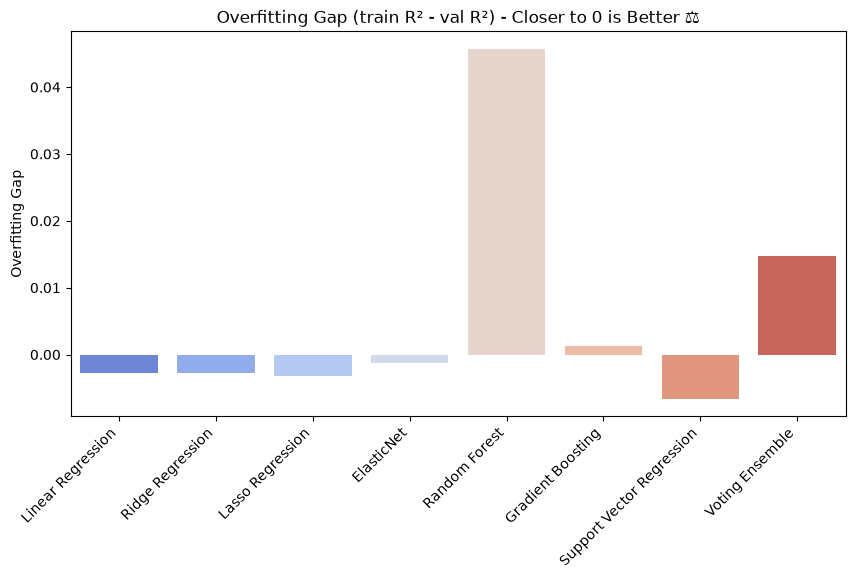

In [99]:
# ===========================
# 1️⃣ Convert results dict to DataFrame
# ===========================
metrics_df = pd.DataFrame(results).T  # transpose so models are rows
metrics_df = metrics_df[['val_r2', 'val_rmse', 'val_mae', 'overfitting_gap', 'cv_r2_mean']]
metrics_df = metrics_df.reset_index().rename(columns={'index': 'Model'})

print("📊 Model comparison table:")
display(metrics_df)

# ===========================
# 2️⃣ Plot Validation R² (Higher is better)
# ===========================
plt.figure(figsize=(10, 5))
sns.barplot(data=metrics_df, x='Model', y='val_r2', palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Validation R² Comparison (Higher is Better ✅)')
plt.ylabel('Validation R²')
plt.xlabel('')
plt.ylim(0, 1)
plt.show()

# ===========================
# 3️⃣ Plot Validation RMSE (Lower is better)
# ===========================
plt.figure(figsize=(10, 5))
sns.barplot(data=metrics_df, x='Model', y='val_rmse', palette='magma')
plt.xticks(rotation=45, ha='right')
plt.title('Validation RMSE Comparison (Lower is Better ✅)')
plt.ylabel('Validation RMSE')
plt.xlabel('')
plt.show()

# ===========================
# 4️⃣ Plot Overfitting Gap (Closer to 0 is better)
# ===========================
plt.figure(figsize=(10, 5))
sns.barplot(data=metrics_df, x='Model', y='overfitting_gap', palette='coolwarm')
plt.xticks(rotation=45, ha='right')
plt.title('Overfitting Gap (train R² - val R²) - Closer to 0 is Better ⚖️')
plt.ylabel('Overfitting Gap')
plt.xlabel('')
plt.show()

📈 ADVANCED MODEL COMPARISON

🏆 MODEL PERFORMANCE RANKING
Model                     Val R²   CV R²        Overfitting  Time (s)  
--------------------------------------------------------------------------------
Random Forest              0.9468  0.9422 ± 0.0030   ✅  0.0457      0.61
Gradient Boosting          0.9001  0.8937 ± 0.0038   ✅  0.0013      1.33
Voting Ensemble            0.8664  0.8568 ± 0.0041   ✅  0.0148      2.45
Ridge Regression           0.4007  0.3966 ± 0.0155   ✅ -0.0027      0.01
Linear Regression          0.4007  0.3966 ± 0.0155   ✅ -0.0027      0.01
Lasso Regression           0.3984  0.3940 ± 0.0156   ✅ -0.0031      0.02
Support Vector Regression  0.3720  0.3468 ± 0.0240   ✅ -0.0066      7.18
ElasticNet                 0.3223  0.3204 ± 0.0141   ✅ -0.0012      0.00


/var/folders/6_/_ffygjtd70b4hxh0dgzrnc500000gp/T/ipykernel_27238/356312245.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0, 1].set_xticklabels(models_ordered, rotation=45, ha='right')
/var/folders/6_/_ffygjtd70b4hxh0dgzrnc500000gp/T/ipykernel_27238/356312245.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1, 0].set_xticklabels(models_ordered, rotation=45, ha='right')
/var/folders/6_/_ffygjtd70b4hxh0dgzrnc500000gp/T/ipykernel_27238/356312245.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1, 1].set_xticklabels(models_ordered, rotation=45, ha='right')


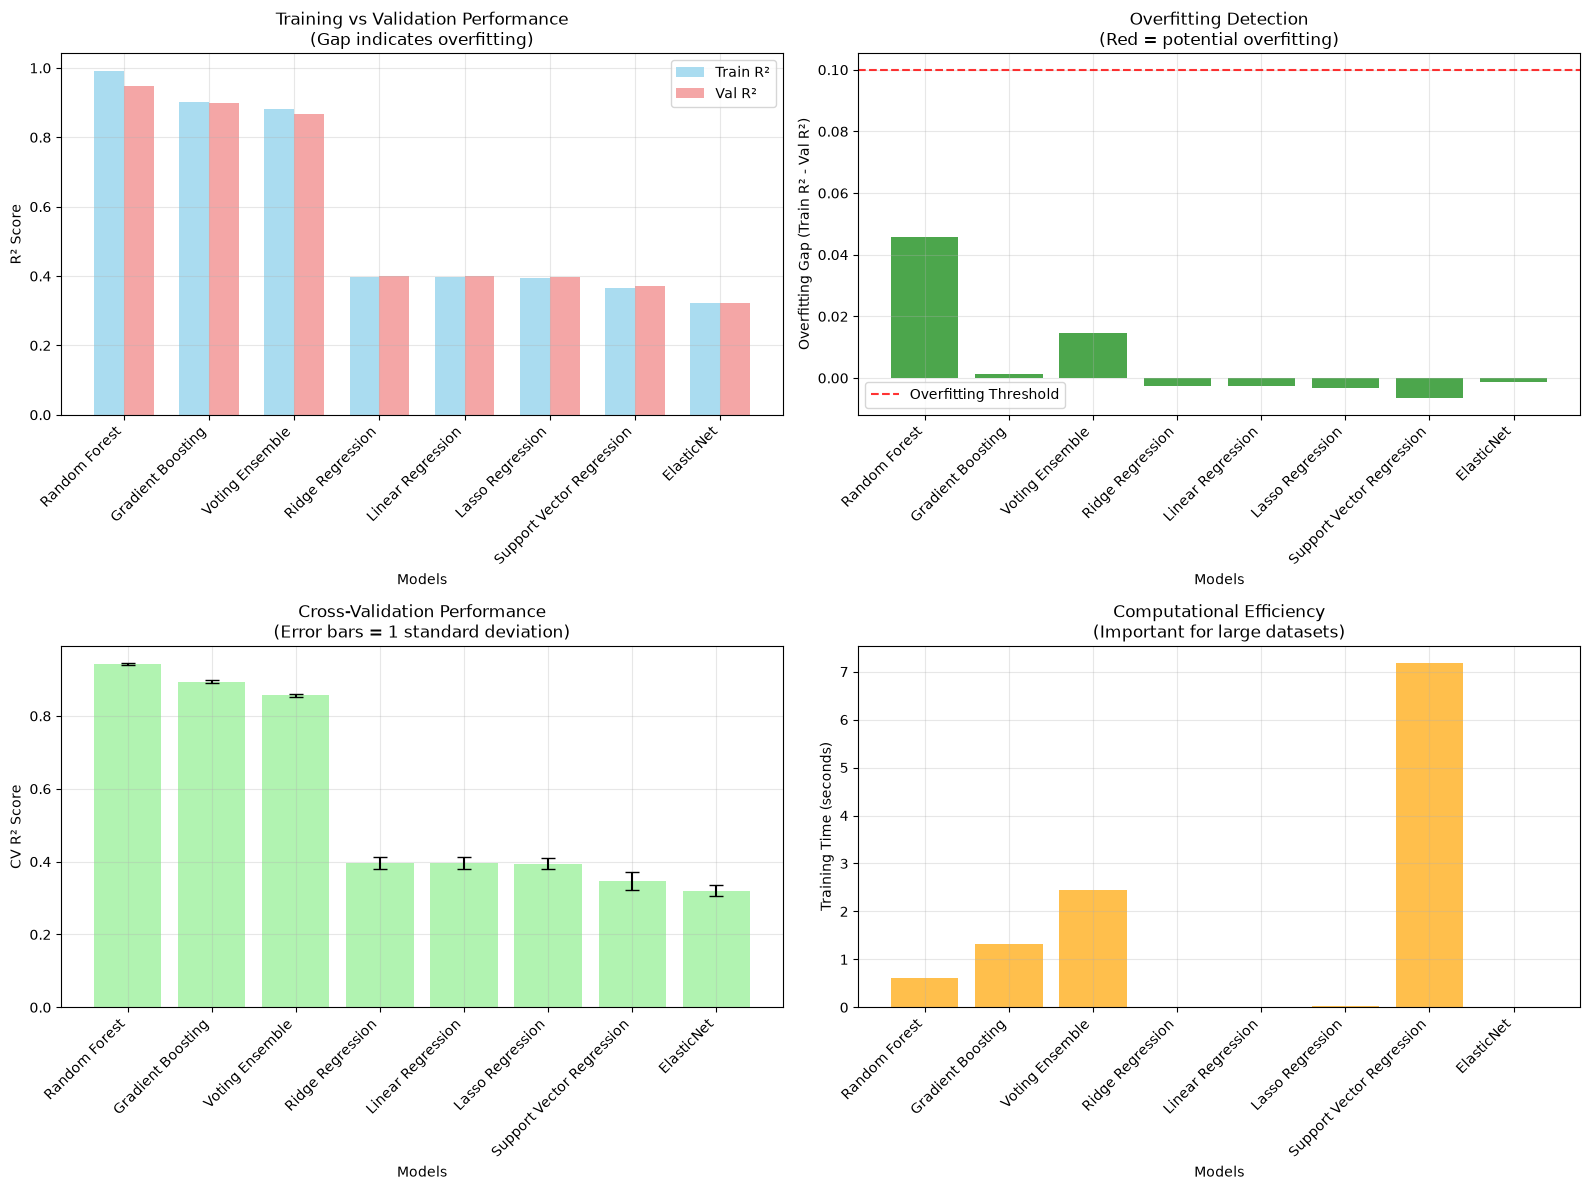


🎯 BEST MODEL SELECTED: Random Forest
📊 Validation R²: 0.9468
🔍 CV R²: 0.9422 ± 0.0030

💡 INTERPRETATION GUIDE:
• Good: High R², small train-val gap, stable CV, reasonable training time
• Overfitting: Large gap between train and validation performance
• Unstable: Large CV standard deviation
• Best choice: Balances performance, stability, and efficiency


In [100]:
# 📈 CELL 7: Advanced Model Comparison Visualization
print("📈 ADVANCED MODEL COMPARISON")

# Create comprehensive results dataframe
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('val_r2', ascending=False)

print("\n" + "=" * 80)
print("🏆 MODEL PERFORMANCE RANKING")
print("=" * 80)
print(f"{'Model':<25} {'Val R²':<8} {'CV R²':<12} {'Overfitting':<12} {'Time (s)':<10}")
print("-" * 80)

for model_name in results_df.index:
    row = results_df.loc[model_name]
    overfitting_indicator = "⚠️" if row['overfitting_gap'] > 0.1 else "✅"
    print(f"{model_name:<25} {row['val_r2']:>7.4f} {row['cv_r2_mean']:>7.4f} ± {row['cv_r2_std']:>5.4f} "
          f"{overfitting_indicator:>3} {row['overfitting_gap']:>7.4f} {row['training_time']:>9.2f}")

# Comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. R² Comparison
models_ordered = results_df.index
val_r2 = [results[model]['val_r2'] for model in models_ordered]
train_r2 = [results[model]['train_r2'] for model in models_ordered]

x = np.arange(len(models_ordered))
width = 0.35

axes[0, 0].bar(x - width/2, train_r2, width, label='Train R²', alpha=0.7, color='skyblue')
axes[0, 0].bar(x + width/2, val_r2, width, label='Val R²', alpha=0.7, color='lightcoral')
axes[0, 0].set_xlabel('Models')
axes[0, 0].set_ylabel('R² Score')
axes[0, 0].set_title('Training vs Validation Performance\n(Gap indicates overfitting)')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(models_ordered, rotation=45, ha='right')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Overfitting Analysis
overfitting_gaps = [results[model]['overfitting_gap'] for model in models_ordered]
colors = ['red' if gap > 0.1 else 'green' for gap in overfitting_gaps]
axes[0, 1].bar(models_ordered, overfitting_gaps, color=colors, alpha=0.7)
axes[0, 1].axhline(y=0.1, color='red', linestyle='--', alpha=0.8, label='Overfitting Threshold')
axes[0, 1].set_xlabel('Models')
axes[0, 1].set_ylabel('Overfitting Gap (Train R² - Val R²)')
axes[0, 1].set_title('Overfitting Detection\n(Red = potential overfitting)')
axes[0, 1].set_xticklabels(models_ordered, rotation=45, ha='right')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Cross-Validation Stability
cv_means = [results[model]['cv_r2_mean'] for model in models_ordered]
cv_stds = [results[model]['cv_r2_std'] for model in models_ordered]
axes[1, 0].bar(models_ordered, cv_means, yerr=cv_stds, capsize=5, alpha=0.7, color='lightgreen')
axes[1, 0].set_xlabel('Models')
axes[1, 0].set_ylabel('CV R² Score')
axes[1, 0].set_title('Cross-Validation Performance\n(Error bars = 1 standard deviation)')
axes[1, 0].set_xticklabels(models_ordered, rotation=45, ha='right')
axes[1, 0].grid(True, alpha=0.3)

# 4. Computational Efficiency
training_times = [results[model]['training_time'] for model in models_ordered]
axes[1, 1].bar(models_ordered, training_times, alpha=0.7, color='orange')
axes[1, 1].set_xlabel('Models')
axes[1, 1].set_ylabel('Training Time (seconds)')
axes[1, 1].set_title('Computational Efficiency\n(Important for large datasets)')
axes[1, 1].set_xticklabels(models_ordered, rotation=45, ha='right')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Select best model
best_model_name = results_df.index[0]
best_model = trained_models[best_model_name]
print(f"\n🎯 BEST MODEL SELECTED: {best_model_name}")
print(f"📊 Validation R²: {results_df.iloc[0]['val_r2']:.4f}")
print(f"🔍 CV R²: {results_df.iloc[0]['cv_r2_mean']:.4f} ± {results_df.iloc[0]['cv_r2_std']:.4f}")

print("\n💡 INTERPRETATION GUIDE:")
print("• Good: High R², small train-val gap, stable CV, reasonable training time")
print("• Overfitting: Large gap between train and validation performance")
print("• Unstable: Large CV standard deviation")
print("• Best choice: Balances performance, stability, and efficiency")

## Hyperparameter Optimization

Machine learning models have **hyperparameters**—settings that control how the model learns.  
Choosing the right hyperparameters can dramatically improve performance.

- **Default parameters** are rarely optimal.  
- **Systematic search** (like `RandomizedSearchCV`) explores different combinations efficiently.  
- **MLflow tracking** logs all experiments, making it easy to compare results.  

In this section, we will tune hyperparameters for several models:
- Random Forest
- Gradient Boosting
- Ridge Regression
- Voting Ensemble

> 🎯 Goal: Find the best configurations that maximize model performance while preventing overfitting.

In [101]:
# Define comprehensive hyperparameter grids
param_grids = {
    'Random Forest': {
        'n_estimators': [50, 100, 200, 300],  # Number of trees
        'max_depth': [None, 10, 20, 30],       # Tree depth
        'min_samples_split': [2, 5, 10],       # Minimum samples to split
        'min_samples_leaf': [1, 2, 4],         # Minimum samples per leaf
        'max_features': ['auto', 'sqrt', 'log2']  # Features to consider for splits
    },
    
    'Gradient Boosting': {
        'n_estimators': [50, 100, 200],        # Number of boosting stages
        'learning_rate': [0.01, 0.05, 0.1, 0.2],  # Step size shrinkage
        'max_depth': [3, 4, 5, 6],             # Maximum depth per tree
        'min_samples_split': [2, 5, 10],       # Minimum samples to split
        'subsample': [0.8, 0.9, 1.0]           # Fraction of samples for fitting
    },
    
    'Ridge Regression': {
        'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],  # Regularization strength
        'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga']  # Algorithm
    },
    
    'Voting Ensemble': {
        'ridge__alpha': [0.1, 1.0, 10.0],
        'rf__n_estimators': [50, 100],
        'rf__max_depth': [10, 20],
        'gb__n_estimators': [50, 100],
        'gb__learning_rate': [0.05, 0.1]
    }
} 

##  Steps: Hyperparameter Optimization

1. **Initialize storage**  
   - `tuned_models` will store the best model for each algorithm.  
   - `optimization_results` will store the best score and parameters for each model.

2. **Loop over each model**  
   - Models: Random Forest, Gradient Boosting, Ridge Regression, Voting Ensemble.  

3. **Start MLflow tracking**  
   - Each model tuning run is logged with `mlflow.start_run(run_name=model_name_tuned)`.

4. **Run RandomizedSearchCV**  
   - Tries `n_iter=20` random combinations from the model’s hyperparameter grid.  
   - Uses cross-validation (`cv=config.CV_FOLDS`) to estimate performance.  
   - Scores models using R² (`scoring='r2'`).

5. **Fit the search**  
   - Fits the model on the training data and finds the best hyperparameters.

6. **Store best results**  
   - Best model saved in `tuned_models`.  
   - Best score and parameters saved in `optimization_results`.

7. **Log everything to MLflow**  
   - Hyperparameters, best cross-validation score, and the tuned model artifact.

8. **Print summary**  
   - Shows best CV R² and the parameters found for each model.

> 🎯 Goal: Automatically find the best hyperparameter settings to maximize model performance while keeping tracking and reproducibility simple.

In [103]:
# Perform hyperparameter optimization
print("🎯 STARTING HYPERPARAMETER OPTIMIZATION...")
tuned_models = {}
optimization_results = {}

for model_name in ['Random Forest', 'Gradient Boosting', 'Ridge Regression', 'Voting Ensemble']:
    print(f"\n🔧 Tuning {model_name}...")
    
    with mlflow.start_run(run_name=f"{model_name}_tuned"):
        # Use RandomizedSearchCV for efficient optimization
        search = RandomizedSearchCV(
            advanced_models[model_name],
            param_grids[model_name],
            n_iter=20,  # Try 20 random combinations (efficient!)
            cv=config.CV_FOLDS,
            scoring='r2',
            n_jobs=1,
            random_state=config.RANDOM_STATE,
            verbose=1
        )
        
        # Perform the search
        search.fit(X_train, y_train)
        
        # Store results
        tuned_models[model_name] = search.best_estimator_
        optimization_results[model_name] = {
            'best_score': search.best_score_,
            'best_params': search.best_params_,
            'best_estimator': search.best_estimator_
        }
        
        # Log to MLflow
        mlflow.log_params(search.best_params_)
        mlflow.log_metric('best_cv_score', search.best_score_)
        mlflow.sklearn.log_model(search.best_estimator_, "tuned_model", skops_trusted_types=[
        "sklearn.utils._bunch.Bunch"])
        
        print(f"✅ {model_name:20} | Best CV R²: {search.best_score_:.4f}")
        print(f"   Best parameters found: {search.best_params_}")

print(f"\n🎉 HYPERPARAMETER OPTIMIZATION COMPLETE!")
print(f"💡 All tuned models saved in MLflow for comparison")

🎯 STARTING HYPERPARAMETER OPTIMIZATION...

🔧 Tuning Random Forest...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


/Users/usertwo/loka/two/project/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:493: FitFailedWarning: 
15 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/usertwo/loka/two/project/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 855, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/usertwo/loka/two/project/.venv/lib/python3.12/site-packages/sklearn/base.py", line 1393, in wrapper
    estimator._validate_params()
  File "/Users/usertwo/loka/two/project/.venv/lib/python3.12/site-packages/sklearn/base.py", line 554, in _valida

✅ Random Forest        | Best CV R²: 0.9222
   Best parameters found: {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}

🔧 Tuning Gradient Boosting...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


2026/09/15 12:47:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/15 12:47:19 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


✅ Gradient Boosting    | Best CV R²: 0.9498
   Best parameters found: {'subsample': 0.8, 'n_estimators': 200, 'min_samples_split': 2, 'max_depth': 6, 'learning_rate': 0.05}

🔧 Tuning Ridge Regression...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


2026/09/15 12:47:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/15 12:47:30 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


✅ Ridge Regression     | Best CV R²: 0.3966
   Best parameters found: {'solver': 'sparse_cg', 'alpha': 1.0}

🔧 Tuning Voting Ensemble...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


2026/09/15 12:49:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/15 12:49:53 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


✅ Voting Ensemble      | Best CV R²: 0.8567
   Best parameters found: {'ridge__alpha': 0.1, 'rf__n_estimators': 100, 'rf__max_depth': 20, 'gb__n_estimators': 100, 'gb__learning_rate': 0.1}

🎉 HYPERPARAMETER OPTIMIZATION COMPLETE!
💡 All tuned models saved in MLflow for comparison


📊 Tuned Models Performance:


,Model,Best CV R²
0,Random Forest,0.922200
1,Gradient Boosting,0.949824
2,Ridge Regression,0.396598
3,Voting Ensemble,0.856652


/var/folders/6_/_ffygjtd70b4hxh0dgzrnc500000gp/T/ipykernel_27238/2602597913.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tuned_metrics_df, x='Model', y='Best CV R²', palette='viridis')
/Users/usertwo/loka/two/project/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


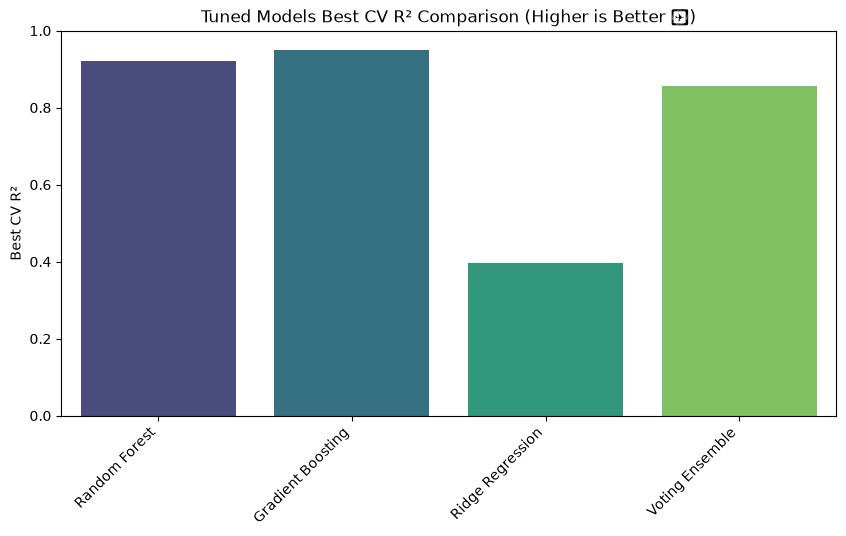

In [104]:
# ===========================
# 1️⃣ Convert optimization results to DataFrame
# ===========================
tuned_metrics_df = pd.DataFrame.from_dict({
    model: {
        'Best CV R²': optimization_results[model]['best_score']
    } for model in optimization_results
}, orient='index').reset_index().rename(columns={'index': 'Model'})

print("📊 Tuned Models Performance:")
display(tuned_metrics_df)

# ===========================
# 2️⃣ Plot Best CV R² (Higher is better)
# ===========================
plt.figure(figsize=(10,5))
sns.barplot(data=tuned_metrics_df, x='Model', y='Best CV R²', palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Tuned Models Best CV R² Comparison (Higher is Better ✅)')
plt.ylabel('Best CV R²')
plt.xlabel('')
plt.ylim(0,1)
plt.show()

Model                Untuned R²   Tuned R²     Improvement 
------------------------------------------------------------
Random Forest            0.9468     0.9342 📉  -0.0126
Gradient Boosting        0.9001     0.9527 📈   0.0526
Ridge Regression         0.4007     0.4007 📈   0.0000
Voting Ensemble          0.8664     0.8661 📉  -0.0002


/var/folders/6_/_ffygjtd70b4hxh0dgzrnc500000gp/T/ipykernel_27238/4253977782.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(models, rotation=45, ha='right')


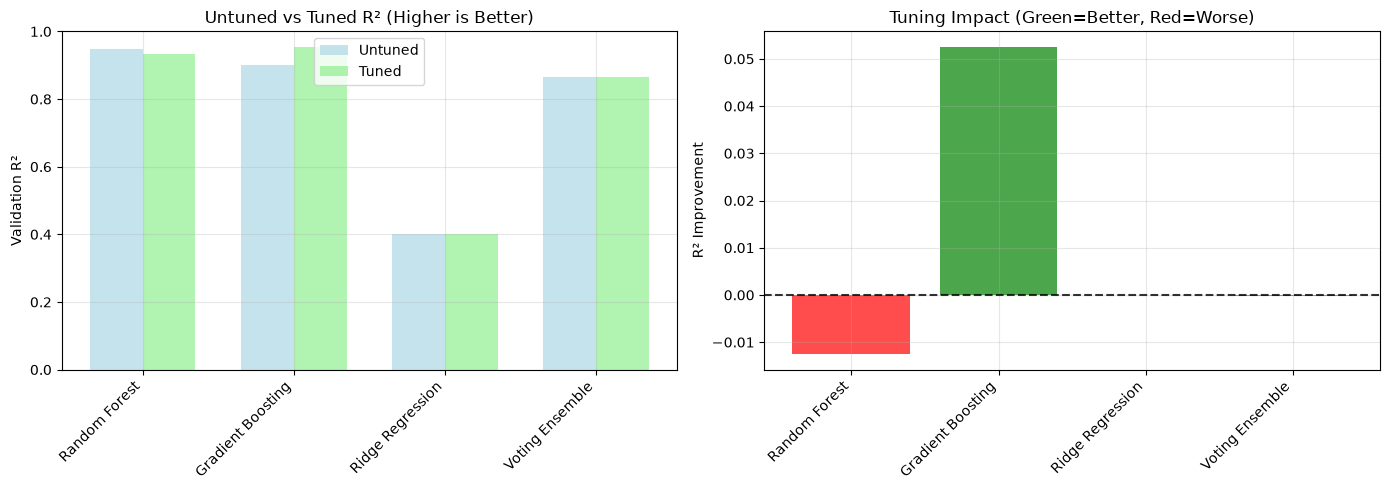


🏆 BEST TUNED MODEL: Gradient Boosting
📊 Validation R²: 0.9527
📈 Improvement over untuned: +0.0526


In [105]:
# ===========================
# 1️⃣ Evaluate tuned models on validation set
# ===========================
tuned_results = {}
for model_name, tuned_model in tuned_models.items():
    y_val_pred = tuned_model.predict(X_val)
    val_r2 = r2_score(y_val, y_val_pred)
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    improvement = val_r2 - results[model_name]['val_r2']  # vs untuned
    
    tuned_results[model_name] = {
        'val_r2': val_r2,
        'val_rmse': val_rmse,
        'improvement': improvement
    }

# ===========================
# 2️⃣ Print simple comparison table
# ===========================
print(f"{'Model':<20} {'Untuned R²':<12} {'Tuned R²':<12} {'Improvement':<12}")
print("-" * 60)
for model_name, res in tuned_results.items():
    untuned_r2 = results[model_name]['val_r2']
    tuned_r2 = res['val_r2']
    improvement = res['improvement']
    icon = "📈" if improvement > 0 else "📉" if improvement < 0 else "➡️"
    print(f"{model_name:<20} {untuned_r2:>10.4f} {tuned_r2:>10.4f} {icon} {improvement:>8.4f}")

# ===========================
# 3️⃣ Plot Tuned vs Untuned R²
# ===========================
models = list(tuned_results.keys())
untuned_r2 = [results[m]['val_r2'] for m in models]
tuned_r2 = [tuned_results[m]['val_r2'] for m in models]
improvement = [tuned_results[m]['improvement'] for m in models]

x = np.arange(len(models))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# R² comparison
axes[0].bar(x - width/2, untuned_r2, width, label='Untuned', alpha=0.7, color='lightblue')
axes[0].bar(x + width/2, tuned_r2, width, label='Tuned', alpha=0.7, color='lightgreen')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=45, ha='right')
axes[0].set_ylabel('Validation R²')
axes[0].set_title('Untuned vs Tuned R² (Higher is Better)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Improvement plot
colors = ['green' if i>0 else 'red' for i in improvement]
axes[1].bar(models, improvement, color=colors, alpha=0.7)
axes[1].axhline(0, color='black', linestyle='--', alpha=0.8)
axes[1].set_ylabel('R² Improvement')
axes[1].set_title('Tuning Impact (Green=Better, Red=Worse)')
axes[1].set_xticklabels(models, rotation=45, ha='right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ===========================
# 4️⃣ Best tuned model
# ===========================
best_model_name = max(tuned_results, key=lambda m: tuned_results[m]['val_r2'])
print(f"\n🏆 BEST TUNED MODEL: {best_model_name}")
print(f"📊 Validation R²: {tuned_results[best_model_name]['val_r2']:.4f}")
print(f"📈 Improvement over untuned: +{tuned_results[best_model_name]['improvement']:.4f}")

# ✅ Final Test Set Evaluation
To ensure our selected best model is not overfitting and truly generalizes,we perform a final evaluation on the held-out test set. 
This step provides an unbiased estimate of how the model will perform on unseen data, which is a standard and critical practice in machine learning before deploying a model to production.


In [106]:
best_tuned_model = tuned_models[best_model_name] # add this line 

# Predict on test set
y_test_pred = best_tuned_model.predict(X_test)

# Compute performance metrics
test_r2 = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)

print(f"📊 Test R²: {test_r2:.4f}")
print(f"📊 Test RMSE: {test_rmse:.4f}")
print(f"📊 Test MAE: {test_mae:.4f}")

📊 Test R²: 0.9528
📊 Test RMSE: 38.6641
📊 Test MAE: 23.7796


In [107]:
import os
import json
import joblib
from datetime import datetime
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# ===========================
# 0️⃣ Prepare feature names
# ===========================
# Works for both DataFrame and NumPy array
try:
    feature_names_all = list(X.columns)
except AttributeError:
    feature_names_all = [f"feature_{i}" for i in range(X.shape[1])]

# ===========================
# 1️⃣ Identify best tuned model
# ===========================
best_model_name = max(tuned_results, key=lambda m: tuned_results[m]['val_r2'])
best_tuned_model = tuned_models[best_model_name]

print(f"🏆 BEST TUNED MODEL: {best_model_name}")
print(f"📊 Validation R²: {tuned_results[best_model_name]['val_r2']:.4f}")
print(f"📈 Improvement over untuned: +{tuned_results[best_model_name]['improvement']:.4f}")

# ===========================
# 2️⃣ Evaluate on Test Set
# ===========================
y_test_pred = best_tuned_model.predict(X_test)
test_r2 = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)

print(f"\n📊 Test Set Performance:")
print(f"R²: {test_r2:.4f} | RMSE: {test_rmse:.4f} | MAE: {test_mae:.4f}")

# ===========================
# 3️⃣ Versioning and saving
# ===========================
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_version = f"v1_{timestamp}"
model_save_dir = os.path.join(config.MODEL_DIR, model_version)
os.makedirs(model_save_dir, exist_ok=True)

# Save model
model_path = os.path.join(model_save_dir, 'best_model.pkl')
joblib.dump(best_tuned_model, model_path)
print(f"✅ Model saved: {model_path}")

# Save preprocessing pipeline
preprocessor_path = os.path.join(model_save_dir, 'preprocessor.pkl')
joblib.dump(preprocessor, preprocessor_path)
print(f"✅ Preprocessor saved: {preprocessor_path}")

# ===========================
# 4️⃣ Create model card
# ===========================
model_card = {
    'model_name': best_model_name,
    'model_version': model_version,
    'timestamp': timestamp,
    'dataset': 'California Housing',
    'target': 'House Price ($M)',
    
    'performance': {
        'test_r2': float(test_r2),
        'test_rmse': float(test_rmse),
        'test_mae': float(test_mae),
        'train_r2': float(results[best_model_name]['train_r2']),
        'val_r2': float(tuned_results[best_model_name]['val_r2']),
        'cv_r2_mean': float(results[best_model_name]['cv_r2_mean']),
        'cv_r2_std': float(results[best_model_name]['cv_r2_std']),
    },
    
    'data_info': {
        'total_samples': int(len(X)),
        'train_samples': int(len(X_train)),
        'val_samples': int(len(X_val)),
        'test_samples': int(len(X_test)),
        'n_features': X_test.shape[1],
        'feature_names': feature_names_all,
    },
    
    'model_config': {
        'model_class': best_model_name,
        'hyperparameters': dict(best_tuned_model.get_params()) 
            if hasattr(best_tuned_model, 'get_params') else {},
    },
    
    'preprocessing': {
        'steps': [
            'AdvancedFeatureEngineering (6 new features)',
            'OutlierHandling (IQR method)',
            'RobustScaler (outlier-resistant scaling)',
        ],
        'outlier_factor': 1.5,
    },
    
    'deployment': {
        'status': 'Ready for Production',
        'recommendations': [
            'Monitor prediction errors in production',
            'Retrain quarterly with new data',
            'Alert if RMSE exceeds $0.50M',
        ]
    }
}

card_path = os.path.join(model_save_dir, 'model_card.json')
with open(card_path, 'w') as f:
    json.dump(model_card, f, indent=2)
print(f"✅ Model card saved: {card_path}")

# ===========================
# 5️⃣ Deployment requirements
# ===========================
requirements = {
    'python': '3.8+',
    'packages': {
        'scikit-learn': '1.0+',
        'numpy': '1.20+',
        'pandas': '1.3+',
        'joblib': '1.0+',
    }
}

req_path = os.path.join(model_save_dir, 'requirements.json')
with open(req_path, 'w') as f:
    json.dump(requirements, f, indent=2)
print(f"✅ Deployment requirements saved: {req_path}")

# ===========================
# 6️⃣ Summary
# ===========================
print("\n💾 DEPLOYMENT PACKAGE READY")
print(f"Location: {model_save_dir}")

🏆 BEST TUNED MODEL: Gradient Boosting
📊 Validation R²: 0.9527
📈 Improvement over untuned: +0.0526

📊 Test Set Performance:
R²: 0.9528 | RMSE: 38.6641 | MAE: 23.7796
✅ Model saved: models/v1_20260915_125234/best_model.pkl
✅ Preprocessor saved: models/v1_20260915_125234/preprocessor.pkl
✅ Model card saved: models/v1_20260915_125234/model_card.json
✅ Deployment requirements saved: models/v1_20260915_125234/requirements.json

💾 DEPLOYMENT PACKAGE READY
Location: models/v1_20260915_125234


In [110]:
"""
Gradio UI
Loads the preprocessor.pkl (AdvancedFeatureEngineer -> OutlierHandler -> RobustScaler)
and best_model.pkl, and predicts hourly rental count (cnt) from raw feature inputs.
"""

import glob
import os

import joblib
import pandas as pd
import gradio as gr

# ---------------------------------------------------------------
# 1. Locate and load the most recently saved model + preprocessor
# ---------------------------------------------------------------
MODEL_DIR = "models"  


def find_latest_run(model_dir=MODEL_DIR):
    candidates = sorted(glob.glob(os.path.join(model_dir, "v1_*")))
    if not candidates:
        raise FileNotFoundError(
            f"No saved model found under '{model_dir}/'. "
            "deployment-packaging cell first, "
            "or edit MODEL_DIR / RUN_DIR below to point at the right folder."
        )
    return candidates[-1]  # timestamps sort lexicographically -> last is newest


RUN_DIR = find_latest_run()
model = joblib.load(os.path.join(RUN_DIR, "best_model.pkl"))
preprocessor = joblib.load(os.path.join(RUN_DIR, "preprocessor.pkl"))

print(f"Loaded model + preprocessor from: {RUN_DIR}")

# Raw feature columns the preprocessor/model pipeline expects,
# in the exact order used during training (X = df.drop(columns=[cnt, casual, registered, dteday]))
FEATURE_ORDER = [
    "instant", "season", "yr", "mnth", "hr", "holiday",
    "weekday", "workingday", "weathersit", "temp", "atemp", "hum", "windspeed",
]


def predict_rentals(instant, season, yr, mnth, hr, holiday,
                     weekday, workingday, weathersit, temp, atemp, hum, windspeed):
    row = pd.DataFrame([{
        "instant": instant,
        "season": season,
        "yr": yr,
        "mnth": mnth,
        "hr": hr,
        "holiday": holiday,
        "weekday": weekday,
        "workingday": workingday,
        "weathersit": weathersit,
        "temp": temp,
        "atemp": atemp,
        "hum": hum,
        "windspeed": windspeed,
    }])[FEATURE_ORDER]

    X_processed = preprocessor.transform(row)
    pred = model.predict(X_processed)[0]
    pred = max(0, round(float(pred)))  # rentals can't be negative or fractional
    return f"{pred} bikes"


# ---------------------------------------------------------------
# 2. Gradio interface
# ---------------------------------------------------------------
examples = [
    # instant, season, yr, mnth, hr, holiday, weekday, workingday, weathersit, temp, atemp, hum, windspeed
    [10000, 3, 1, 7, 17, 0, 3, 1, 1, 0.75, 0.72, 0.45, 0.15],   # summer weekday rush hour, clear
    [10001, 1, 0, 1, 3, 0, 6, 0, 2, 0.20, 0.18, 0.70, 0.30],    # winter weekend night, misty
    [10002, 4, 1, 12, 8, 1, 1, 0, 3, 0.10, 0.08, 0.85, 0.40],   # winter holiday morning, light rain
]

iface = gr.Interface(
    fn=predict_rentals,
    inputs=[
        gr.Number(value=10000, label="Instant (row index)",
                   info="Sequential record index from the original dataset — not a real-world signal, "
                        "kept only because the trained model expects it."),
        gr.Dropdown([1, 2, 3, 4], value=1, label="Season (1=spring, 2=summer, 3=fall, 4=winter)"),
        gr.Dropdown([0, 1], value=1, label="Year (0=2011, 1=2012)"),
        gr.Slider(1, 12, value=6, step=1, label="Month"),
        gr.Slider(0, 23, value=8, step=1, label="Hour of day"),
        gr.Dropdown([0, 1], value=0, label="Holiday (1=yes)"),
        gr.Slider(0, 6, value=3, step=1, label="Weekday (0=Sunday ... 6=Saturday)"),
        gr.Dropdown([0, 1], value=1, label="Working Day (1=yes)"),
        gr.Dropdown([1, 2, 3, 4], value=1,
                    label="Weather (1=clear, 2=mist, 3=light rain/snow, 4=heavy rain/snow)"),
        gr.Slider(0.0, 1.0, value=0.5, step=0.01, label="Temperature (normalized)"),
        gr.Slider(0.0, 1.0, value=0.5, step=0.01, label="Feels-like temperature (normalized)"),
        gr.Slider(0.0, 1.0, value=0.5, step=0.01, label="Humidity (normalized)"),
        gr.Slider(0.0, 1.0, value=0.2, step=0.01, label="Wind speed (normalized)"),
    ],
    outputs=gr.Textbox(label="Predicted Rentals (cnt)"),
    title="🚲 Bike Sharing Demand Predictor",
    description=(
        "Predicts hourly bike rental count from time, weather, and calendar features, "
        "using the tuned model + preprocessing pipeline."
    ),
    examples=examples,
)

iface.launch(share=True)

Loaded model + preprocessor from: models/v1_20260915_125234
* Running on local URL:  http://127.0.0.1:7866
* Running on public URL: https://98b780d61d2325a784.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
